# 02 - Modelos Estadísticos (SARIMA, ETS, Prophet)
## APEAJAL - Pronóstico de Precios de Aguacate Hass en Jalisco

**Nombres y matrículas:**
  * José Antonio Gómez Mora | A01374459
  * Alejandro Chávez Campos | A01374974
  * Laura Patricia Martínez Treviño | A01795967

**Número de Equipo:** 30

**Objetivo:** Evaluar modelos estadísticos clásicos de series temporales para el pronóstico de precios a 6 meses, capturando estacionalidad y tendencia.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install -q prophet

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

plt.style.use('seaborn-v0_8-whitegrid')
BASE = '/content/drive/MyDrive/MNA/proyecto-integrador/processed2/'
HORIZON = 6

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [5]:
sb = pd.read_csv(BASE + 'serie_b_precio_mayorista.csv', parse_dates=['date'])
precio = sb.set_index('date')['precio_promedio'].sort_index().asfreq('MS').interpolate()

sa = pd.read_csv(BASE + 'serie_a_precio_productor.csv', parse_dates=['date'])
prod = sa.set_index('date')['produccion_tons'].sort_index()
prod.index.freq = 'MS'

print(f'Precio: {len(precio)} obs ({precio.index[0].date()} a {precio.index[-1].date()})')
print(f'Producción: {len(prod)} obs ({prod.index[0].date()} a {prod.index[-1].date()})')

Precio: 99 obs (2017-10-01 a 2025-12-01)
Producción: 348 obs (1996-01-01 a 2024-12-01)


## 1. SARIMA

Búsqueda de hiperparámetros por AIC sobre órdenes (p,d,q)×(P,D,Q,12).

In [6]:
train_p, test_p = precio[:-HORIZON], precio[-HORIZON:]

best_aic, best_order, best_seasonal = np.inf, None, None
for p in range(3):
    for q in range(3):
        for P in range(2):
            for Q in range(2):
                try:
                    fit = SARIMAX(train_p, order=(p,1,q), seasonal_order=(P,1,Q,12),
                                  enforce_stationarity=False, enforce_invertibility=False
                                  ).fit(disp=False, maxiter=200)
                    if fit.aic < best_aic:
                        best_aic, best_order, best_seasonal = fit.aic, (p,1,q), (P,1,Q,12)
                except:
                    continue

print(f'Mejor SARIMA: {best_order}x{best_seasonal}  AIC={best_aic:.2f}')

Mejor SARIMA: (1, 1, 2)x(0, 1, 1, 12)  AIC=445.11


In [7]:
fit_sarima = SARIMAX(train_p, order=best_order, seasonal_order=best_seasonal,
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=500)
fc_sarima = fit_sarima.forecast(steps=HORIZON)

mae_s = mean_absolute_error(test_p, fc_sarima)
rmse_s = np.sqrt(mean_squared_error(test_p, fc_sarima))
mape_s = mape(test_p.values, fc_sarima.values)
print(f'SARIMA — MAE: {mae_s:.2f}  RMSE: {rmse_s:.2f}  MAPE: {mape_s:.2f}%')

# Forecast futuro
fit_full = SARIMAX(precio, order=best_order, seasonal_order=best_seasonal,
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=500)
fc_fut = fit_full.get_forecast(steps=HORIZON)
fc_mean = fc_fut.predicted_mean
fc_ci = fc_fut.conf_int()

SARIMA — MAE: 18.16  RMSE: 18.32  MAPE: 42.48%


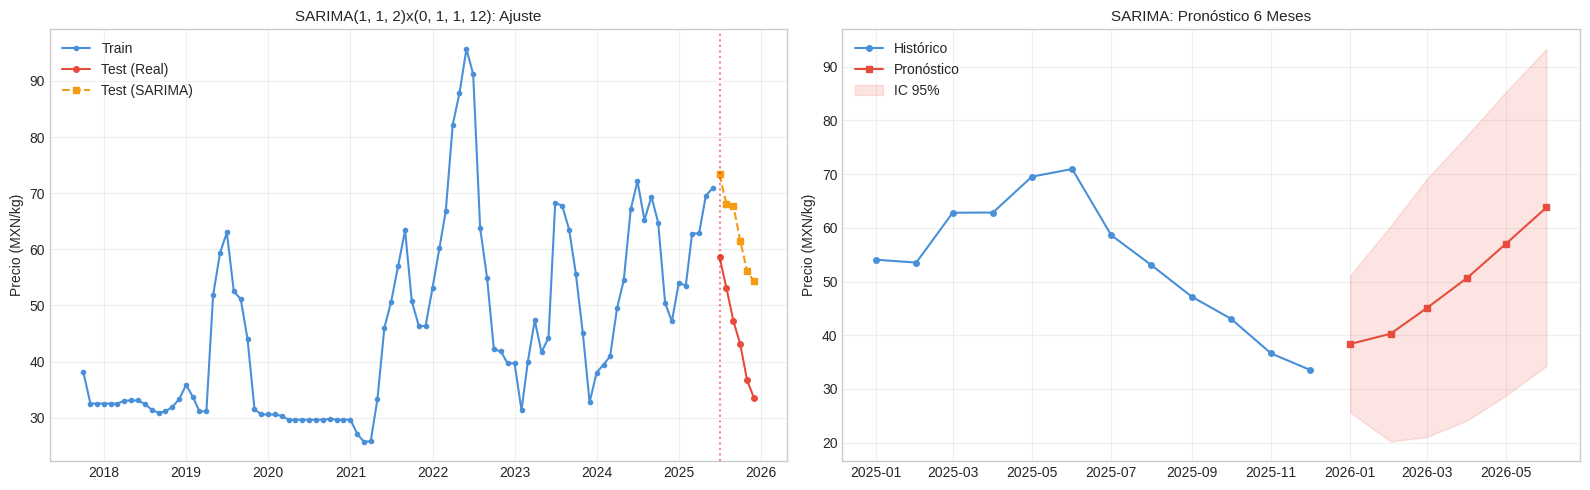

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(train_p.index, train_p, 'o-', color='#4A90D9', ms=3, label='Train')
axes[0].plot(test_p.index, test_p, 'o-', color='#E74C3C', ms=4, label='Test (Real)')
axes[0].plot(test_p.index, fc_sarima, 's--', color='#F39C12', ms=4, label='Test (SARIMA)')
axes[0].axvline(test_p.index[0], color='red', ls=':', alpha=0.5)
axes[0].set_title(f'SARIMA{best_order}x{best_seasonal}: Ajuste', fontsize=11)
axes[0].set_ylabel('Precio (MXN/kg)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

last12 = precio[-12:]
axes[1].plot(last12.index, last12, 'o-', color='#4A90D9', ms=4, label='Histórico')
axes[1].plot(fc_mean.index, fc_mean, 's-', color='#E74C3C', ms=5, label='Pronóstico')
axes[1].fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], color='#E74C3C', alpha=0.15, label='IC 95%')
axes[1].set_title('SARIMA: Pronóstico 6 Meses', fontsize=11)
axes[1].set_ylabel('Precio (MXN/kg)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. ETS (Exponential Smoothing)

Búsqueda de mejor configuración (trend, seasonal, damped) por AIC.

In [9]:
best_aic_e, best_cfg = np.inf, None
for trend in ['add', 'mul', None]:
    for seasonal in ['add', 'mul']:
        for damped in [True, False]:
            if trend is None and damped: continue
            try:
                m = ExponentialSmoothing(train_p, trend=trend, seasonal=seasonal,
                                        seasonal_periods=12, damped_trend=damped)
                fit = m.fit(optimized=True, use_brute=False)
                if fit.aic < best_aic_e:
                    best_aic_e, best_cfg = fit.aic, (trend, seasonal, damped)
            except: continue

trend_e, seasonal_e, damped_e = best_cfg
print(f'Mejor ETS: trend={trend_e}, seasonal={seasonal_e}, damped={damped_e}  AIC={best_aic_e:.2f}')

Mejor ETS: trend=add, seasonal=mul, damped=False  AIC=347.82


In [10]:
fit_ets = ExponentialSmoothing(train_p, trend=trend_e, seasonal=seasonal_e,
                               seasonal_periods=12, damped_trend=damped_e).fit(optimized=True)
fc_ets = fit_ets.forecast(HORIZON)

mae_e = mean_absolute_error(test_p, fc_ets)
rmse_e = np.sqrt(mean_squared_error(test_p, fc_ets))
mape_e = mape(test_p.values, fc_ets.values)
print(f'ETS — MAE: {mae_e:.2f}  RMSE: {rmse_e:.2f}  MAPE: {mape_e:.2f}%')

# Forecast futuro con IC
fit_ets_full = ExponentialSmoothing(precio, trend=trend_e, seasonal=seasonal_e,
                                    seasonal_periods=12, damped_trend=damped_e).fit(optimized=True)
fc_ets_fut = fit_ets_full.forecast(HORIZON)
sims = fit_ets_full.simulate(HORIZON, repetitions=500, error='mul')
ci_lo = sims.quantile(0.025, axis=1)
ci_hi = sims.quantile(0.975, axis=1)

ETS — MAE: 14.78  RMSE: 14.93  MAPE: 33.32%


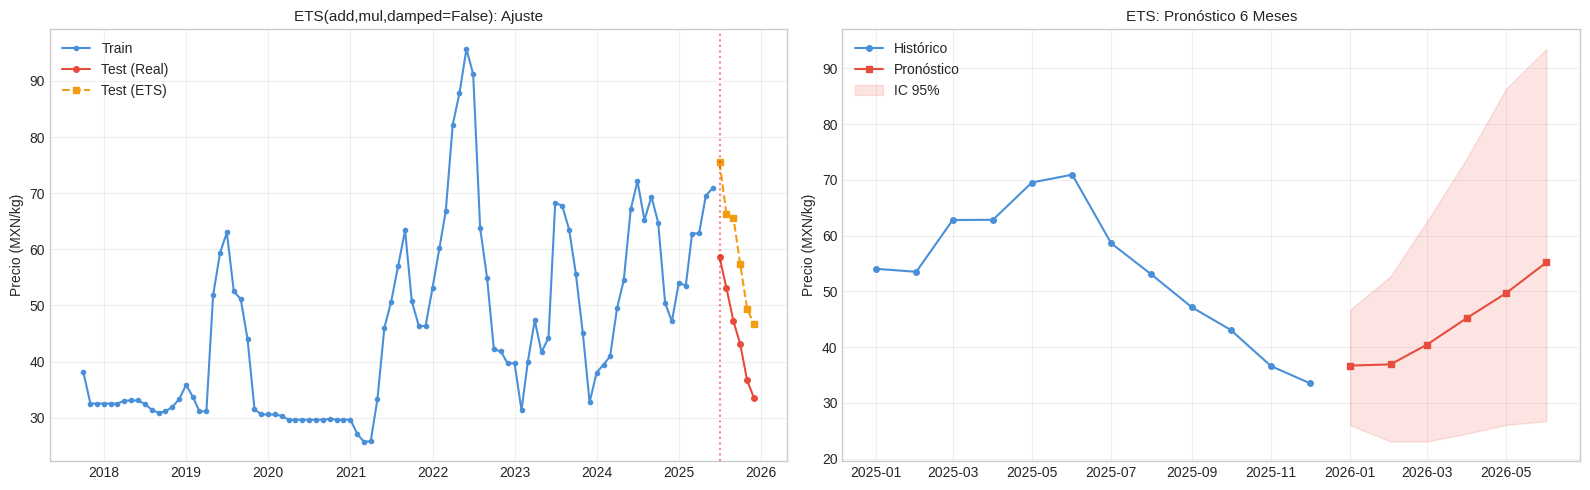

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(train_p.index, train_p, 'o-', color='#4A90D9', ms=3, label='Train')
axes[0].plot(test_p.index, test_p, 'o-', color='#E74C3C', ms=4, label='Test (Real)')
axes[0].plot(test_p.index, fc_ets, 's--', color='#F39C12', ms=4, label='Test (ETS)')
axes[0].axvline(test_p.index[0], color='red', ls=':', alpha=0.5)
axes[0].set_title(f'ETS({trend_e},{seasonal_e},damped={damped_e}): Ajuste', fontsize=11)
axes[0].set_ylabel('Precio (MXN/kg)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(last12.index, last12, 'o-', color='#4A90D9', ms=4, label='Histórico')
axes[1].plot(fc_ets_fut.index, fc_ets_fut, 's-', color='#E74C3C', ms=5, label='Pronóstico')
axes[1].fill_between(ci_lo.index, ci_lo, ci_hi, color='#E74C3C', alpha=0.15, label='IC 95%')
axes[1].set_title('ETS: Pronóstico 6 Meses', fontsize=11)
axes[1].set_ylabel('Precio (MXN/kg)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Prophet

In [12]:
df_prophet = sb[['date','precio_promedio']].rename(columns={'date':'ds','precio_promedio':'y'}).sort_values('ds').reset_index(drop=True)
train_pr, test_pr = df_prophet[:-HORIZON].copy(), df_prophet[-HORIZON:].copy()

m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
            changepoint_prior_scale=0.1, seasonality_prior_scale=15.0)
m.fit(train_pr)

future_test = m.make_future_dataframe(periods=HORIZON, freq='MS')
fc_pr = m.predict(future_test)
fc_pr_test = fc_pr[fc_pr['ds'].isin(test_pr['ds'])]

y_true_pr = test_pr['y'].values
y_pred_pr = fc_pr_test['yhat'].values
mae_p = mean_absolute_error(y_true_pr, y_pred_pr)
rmse_p = np.sqrt(mean_squared_error(y_true_pr, y_pred_pr))
mape_p = mape(y_true_pr, y_pred_pr)
print(f'Prophet — MAE: {mae_p:.2f}  RMSE: {rmse_p:.2f}  MAPE: {mape_p:.2f}%')

Prophet — MAE: 17.95  RMSE: 18.17  MAPE: 42.15%


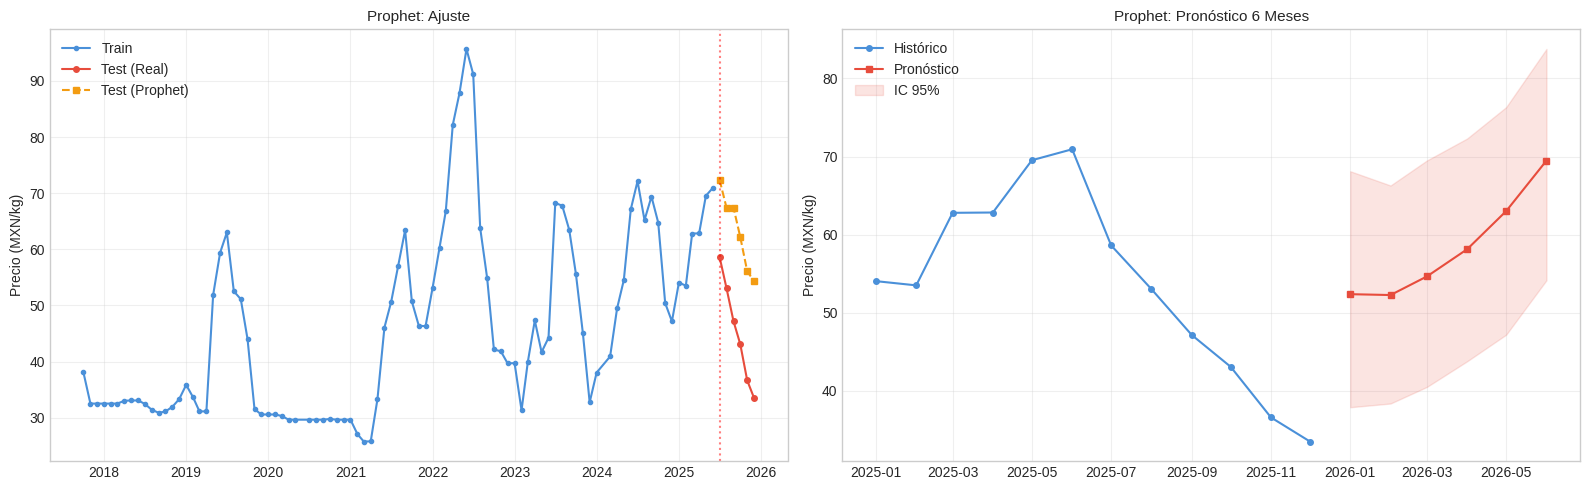

In [13]:
# Forecast futuro
m_full = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
                 changepoint_prior_scale=0.1, seasonality_prior_scale=15.0)
m_full.fit(df_prophet)
future_full = m_full.make_future_dataframe(periods=HORIZON, freq='MS')
fc_full_pr = m_full.predict(future_full)
fc_fut_pr = fc_full_pr.tail(HORIZON)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(train_pr['ds'], train_pr['y'], 'o-', color='#4A90D9', ms=3, label='Train')
axes[0].plot(test_pr['ds'], y_true_pr, 'o-', color='#E74C3C', ms=4, label='Test (Real)')
axes[0].plot(test_pr['ds'], y_pred_pr, 's--', color='#F39C12', ms=4, label='Test (Prophet)')
axes[0].axvline(test_pr['ds'].iloc[0], color='red', ls=':', alpha=0.5)
axes[0].set_title('Prophet: Ajuste', fontsize=11)
axes[0].set_ylabel('Precio (MXN/kg)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

last12_pr = df_prophet[-12:]
axes[1].plot(last12_pr['ds'], last12_pr['y'], 'o-', color='#4A90D9', ms=4, label='Histórico')
axes[1].plot(fc_fut_pr['ds'], fc_fut_pr['yhat'], 's-', color='#E74C3C', ms=5, label='Pronóstico')
axes[1].fill_between(fc_fut_pr['ds'], fc_fut_pr['yhat_lower'], fc_fut_pr['yhat_upper'],
                     color='#E74C3C', alpha=0.15, label='IC 95%')
axes[1].set_title('Prophet: Pronóstico 6 Meses', fontsize=11)
axes[1].set_ylabel('Precio (MXN/kg)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Resumen Modelos Estadísticos

In [14]:
resumen = pd.DataFrame([
    {'Modelo': f'SARIMA{best_order}x{best_seasonal}', 'MAE': mae_s, 'RMSE': rmse_s, 'MAPE': mape_s},
    {'Modelo': f'ETS({trend_e},{seasonal_e},damped={damped_e})', 'MAE': mae_e, 'RMSE': rmse_e, 'MAPE': mape_e},
    {'Modelo': 'Prophet', 'MAE': mae_p, 'RMSE': rmse_p, 'MAPE': mape_p},
]).sort_values('MAPE')
resumen.style.format({'MAE':'{:.2f}','RMSE':'{:.2f}','MAPE':'{:.2f}%'}).highlight_min(subset=['MAPE'], color='lightgreen')

,Modelo,MAE,RMSE,MAPE
1,"ETS(add,mul,damped=False)",14.78,14.93,33.32%
2,Prophet,17.95,18.17,42.15%
0,"SARIMA(1, 1, 2)x(0, 1, 1, 12)",18.16,18.32,42.48%


## 5. Conclusiones

- Los modelos estadísticos capturan la estacionalidad pero tienen MAPE alto (33-42%) en horizonte de 6 meses
- ETS con estacionalidad multiplicativa obtiene el mejor desempeño entre los estadísticos
- La serie corta (97 obs) limita la capacidad de estos modelos para capturar patrones complejos
- Los intervalos de confianza son amplios, reflejando la incertidumbre inherente